# Task: GNN training on synthetic SPV simulations: adjacency, cell state and property matrices

We willl be developing a graph neural network (GNN)-based model capable of inferring mechanistic rules and uncovering the principles driving DPAC aggregation. To facilitate this, the GNN will initially be trained using synthetic Self-Propelled Voronoi (SPV) simulations, serving as placeholder data while the deep learning infrastructure is optimized. The GNN will be validated by its ability to, first, recover the physical mechanisms embedded in the SPV model, then subsequently applied to DPAC data to explore the impacts of initial thickness and cell density.

### GNN training

In [10]:
import os
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from pysr import PySRRegressor
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
from torch_geometric.utils import from_networkx, add_self_loops
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.nn import MessagePassing


In [6]:
import os
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from pysr import PySRRegressor
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
from torch_geometric.utils import from_networkx, add_self_loops
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.nn import MessagePassing
from sklearn.model_selection import KFold



# Function to load matrices from a directory
def load_matrices(directory, timepoint):
    """
    Load the graph, properties, and state matrices for a specific timepoint.
    """
    graph_mat = np.load(os.path.join(directory, f"{timepoint}_graph_mat.npy"))
    properties_mat = np.load(os.path.join(directory, f"{timepoint}_properties_mat.npy"))
    state_mat = np.load(os.path.join(directory, f"{timepoint}_state_mat.npy"))
    return graph_mat, properties_mat, state_mat

# Parse parameters from .py files
def parse_parameters(param_path):
    """
    Parse parameters from the given file.
    """
    params = {}
    print(f"Parsing parameters from {param_path}")
    with open(param_path, "r") as f:
        exec(f.read(), {}, params)  # Execute the file content in a controlled namespace
    print(f"Parsed parameters: {params}")
    return params

# Initialize GCA graph with dynamically parsed params
def initialize_gca(graph_mat, properties_mat, state_mat, params):
    """
    Create a NetworkX graph with node and edge properties for GCA initialization.
    Dynamically updates graph structure based on adjacency matrix.
    """
    # Create a graph from the adjacency matrix
    g = nx.from_numpy_array(graph_mat, create_using=nx.Graph)

    # Access parameters
    v0 = params["v0"]
    Dr = params["Dr"]
    kappa_A = params["kappa_A"]
    kappa_P = params["kappa_P"]
    a = params["a"]
    k = params["k"]
    W = params["W"]  # 2x2 matrix for interfacial energies
    A0 = params["A0"]
    P0 = params["P0"]

    # Add node properties
    for i, (area, perimeter) in enumerate(properties_mat):
        cell_type = np.argmax(state_mat[i])  # Get the dominant cell type
        g.nodes[i]["cell_type"] = cell_type
        g.nodes[i]["motility"] = v0[cell_type]  # Assign motility based on cell type
        g.nodes[i]["area"] = area
        g.nodes[i]["perimeter"] = perimeter
        g.nodes[i]["persistence"] = Dr
        g.nodes[i]["kappa_A"] = kappa_A
        g.nodes[i]["kappa_P"] = kappa_P

    # Add edge properties
    for u, v in g.edges():
        type_u, type_v = g.nodes[u]["cell_type"], g.nodes[v]["cell_type"]
        adhesion = W[type_u][type_v]  # Fetch adhesion value from W matrix
        g.edges[u, v]["adhesion"] = adhesion
        g.edges[u, v]["repulsion_radius"] = a
        g.edges[u, v]["repulsion_coefficient"] = k

    # Attach adjacency matrix to the graph for dynamic updates during training
    g.graph["adj_matrix"] = graph_mat

    return g


def initialize_gca_once(data_dirs, param_files, timepoints, timepoint_interval):
    """
    Pre-initialize GCAs for all timepoints and directories.
    Includes adjacency matrix for training dynamic graph structure.
    """
    print("Pre-initializing GCAs and matrices for all timepoints...")
    gca_data = []
    for dir_idx, (data_dir, param_file) in enumerate(zip(data_dirs, param_files)):
        print(f"Processing directory {data_dir} with parameter file {param_file}...")
        params = parse_parameters(param_file)
        fold_data = {}
        for t in range(0, timepoints, timepoint_interval):
            graph_mat, properties_mat, state_mat = load_matrices(data_dir, t)
            gca_graph = initialize_gca(graph_mat, properties_mat, state_mat, params)
            fold_data[t] = {
                "gca_graph": gca_graph,
                "state_mat": state_mat,
                "graph_mat": graph_mat  # Save the initial adjacency matrix
            }
        gca_data.append(fold_data)
    print("Pre-initialization complete.")
    return gca_data

# Define GNN model
class GNNTransitionRule(MessagePassing):
    def __init__(self, node_dim, edge_dim, hidden_dim, output_dim):
        super(GNNTransitionRule, self).__init__(aggr="add")  # Use "add" aggregation for message passing
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, edge_dim),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        self.adj_predictor = nn.Sequential(
            nn.Linear(2 * node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # Output a single value per edge
            nn.Sigmoid()  # Ensure values are between 0 and 1
        )

    def forward(self, x, edge_index, edge_attr):
        """
        Forward pass for the GNN layer.
        Dynamically adjusts edge attributes to match edge index size.
        """
        # Add self-loops to the graph
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        if edge_attr is not None:
            num_existing_edges = edge_attr.size(0)
            num_edges = edge_index.size(1)

            if num_existing_edges < num_edges:
                # Add zero-padding for missing edge attributes
                num_missing_edges = num_edges - num_existing_edges
                padding = torch.zeros(
                    (num_missing_edges, edge_attr.size(1)), device=edge_attr.device
                )
                edge_attr = torch.cat([edge_attr, padding], dim=0)
        else:
            # Initialize edge attributes if none exist
            edge_attr = torch.zeros((edge_index.size(1), 1), device=x.device)

        # Ensure sizes match
        assert edge_attr.size(0) == edge_index.size(1), (
            f"Mismatch between edge attributes ({edge_attr.size(0)}) and edge indices ({edge_index.size(1)})"
        )

        # Propagate messages through the GNN
        edge_attr = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        # Predict the new adjacency matrix
        predicted_adj = self.predict_adjacency(x, edge_index)

        return edge_attr, predicted_adj

    def message(self, x_i, x_j, edge_attr):
        """
        Compute messages for the GNN layer.
        """
        edge_input = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return self.edge_mlp(edge_input)

    def update(self, aggr_out, x):
        """
        Update node features based on aggregated messages.
        """
        node_input = torch.cat([x, aggr_out], dim=-1)
        return self.node_mlp(node_input)

    def predict_adjacency(self, x, edge_index):
        """
    Predict the adjacency matrix based on node features.
        """
    # Extract features for each edge in edge_index
        src, dst = edge_index
        edge_features = torch.cat([x[src], x[dst]], dim=-1)

    # Predict edge existence probability only for edges in edge_index
        predicted_adj = self.adj_predictor(edge_features)

        return predicted_adj
        


# Update GNCA wrapper model
class GNCA(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, output_dim):
        super(GNCA, self).__init__()
        self.transition_rule = GNNTransitionRule(node_dim, edge_dim, hidden_dim, output_dim)

    def forward(self, x, edge_index, edge_attr):
        edge_attr, predicted_adj = self.transition_rule(x, edge_index, edge_attr)
        return edge_attr, predicted_adj

# Training loop with adjacency matrix update
def k_fold_training(data_dirs, gca_data, timepoint_interval, node_dim, edge_dim, hidden_dim, output_dim, epochs, learning_rate, k_folds):
    """
    Perform k-fold cross-validation on GNN with adjacency matrix prediction.
    """
    fold_results = []
    best_model = None
    best_loss = float('inf')

    # Create k-fold splits
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    data_indices = list(range(len(data_dirs)))

    for fold, (train_indices, val_indices) in enumerate(kf.split(data_indices)):
        print(f"Starting Fold {fold + 1}/{k_folds}")

        # Split training and validation data
        training_data = {i: gca_data[i] for i in train_indices}
        validation_data = {i: gca_data[i] for i in val_indices}

        # Initialize the model, optimizer, and loss functions
        model = GNCA(node_dim, edge_dim, hidden_dim, output_dim)
        optimizer = Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()  # For node state predictions
        criterion_adj = nn.BCELoss()  # Use BCE loss for adjacency matrix (binary classification)

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs} - Fold {fold + 1}")
            epoch_loss = 0.0

            for train_set in training_data.values():
                for t, gca_entry in train_set.items():
                    # Prepare data (nodes, edges, and adjacency)
                    data = from_networkx(gca_entry["gca_graph"])
                    
                    node_features = [
                        [
                            gca_entry["gca_graph"].nodes[i]["cell_type"],
                            gca_entry["gca_graph"].nodes[i]["motility"],
                            gca_entry["gca_graph"].nodes[i]["area"],
                            gca_entry["gca_graph"].nodes[i]["perimeter"],
                            gca_entry["gca_graph"].nodes[i]["persistence"],
                            gca_entry["gca_graph"].nodes[i]["kappa_A"],
                            gca_entry["gca_graph"].nodes[i]["kappa_P"],
                        ]
                        for i in range(len(gca_entry["gca_graph"].nodes))
                    ]
                    data.x = torch.tensor(node_features, dtype=torch.float32)

                    edge_features = [d["adhesion"] for _, _, d in gca_entry["gca_graph"].edges(data=True)]
                    data.edge_attr = torch.tensor(edge_features, dtype=torch.float32).unsqueeze(-1)

                    adj_target_dense = torch.tensor(nx.to_numpy_array(gca_entry["gca_graph"]), dtype=torch.float32)

                    # Forward pass
                    optimizer.zero_grad()
                    pred_states, pred_adj_sparse = model(data.x, data.edge_index, data.edge_attr)

                    # Convert sparse adjacency predictions to dense
                    pred_adj_dense = torch.zeros_like(adj_target_dense)
                    edge_index_np = data.edge_index.cpu().numpy()
                    for idx, (u, v) in enumerate(zip(edge_index_np[0], edge_index_np[1])):
                        pred_adj_dense[u, v] = pred_adj_sparse[idx]

                    # Compute losses
                    loss_states = criterion(pred_states, torch.tensor(gca_entry["state_mat"], dtype=torch.float32))
                    loss_adj = criterion_adj(pred_adj_dense, adj_target_dense)
                    total_loss = loss_states + loss_adj

                    # Backpropagation
                    total_loss.backward()
                    optimizer.step()

                    epoch_loss += total_loss.item()

            print(f"Epoch {epoch + 1}/{epochs} - Fold {fold + 1} - Loss: {epoch_loss:.4f}")

        # Validation loop
        validation_loss = 0.0
        with torch.no_grad():
            for val_set in validation_data.values():
                for t, gca_entry in val_set.items():
                    # Prepare validation data
                    data = from_networkx(gca_entry["gca_graph"])
                    node_features = [
                        [
                            gca_entry["gca_graph"].nodes[i]["cell_type"],
                            gca_entry["gca_graph"].nodes[i]["motility"],
                            gca_entry["gca_graph"].nodes[i]["area"],
                            gca_entry["gca_graph"].nodes[i]["perimeter"],
                            gca_entry["gca_graph"].nodes[i]["persistence"],
                            gca_entry["gca_graph"].nodes[i]["kappa_A"],
                            gca_entry["gca_graph"].nodes[i]["kappa_P"],
                        ]
                        for i in range(len(gca_entry["gca_graph"].nodes))
                    ]
                    data.x = torch.tensor(node_features, dtype=torch.float32)

                    edge_features = [d["adhesion"] for _, _, d in gca_entry["gca_graph"].edges(data=True)]
                    data.edge_attr = torch.tensor(edge_features, dtype=torch.float32).unsqueeze(-1)

                    adj_target_dense = torch.tensor(nx.to_numpy_array(gca_entry["gca_graph"]), dtype=torch.float32)

                    # Forward pass
                    pred_states, pred_adj_sparse = model(data.x, data.edge_index, data.edge_attr)

                    # Convert sparse adjacency predictions to dense
                    pred_adj_dense = torch.zeros_like(adj_target_dense)
                    edge_index_np = data.edge_index.cpu().numpy()
                    for idx, (u, v) in enumerate(zip(edge_index_np[0], edge_index_np[1])):
                        pred_adj_dense[u, v] = pred_adj_sparse[idx]

                    # Compute validation losses
                    loss_states = criterion(pred_states, torch.tensor(gca_entry["state_mat"], dtype=torch.float32))
                    loss_adj = criterion_adj(pred_adj_dense, adj_target_dense)
                    validation_loss += loss_states.item() + loss_adj.item()

        avg_val_loss = validation_loss / len(validation_data)
        fold_results.append(avg_val_loss)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_model = model

    # Save the best model
    torch.save(best_model.state_dict(), "best_model.pth")
    print(f"Best model saved with validation loss: {best_loss:.4f}")
    return fold_results




/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [4]:
# Initialize parameter parsing

if __name__ == "__main__":
    data_dirs = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I_matrix/{i}_matrix_output"
        for i in range(1, 10)
    ]
    param_files = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/{i}.py"
        for i in range(1, 10)
    ]
    timepoints = 500
    timepoint_interval = 4
    node_dim = 7
    edge_dim = 1
    hidden_dim = 16
    output_dim = 2
    epochs = 5
    learning_rate = 1e-3
    k_folds = 2

    gca_data = initialize_gca_once(data_dirs, param_files, timepoints, timepoint_interval)


Pre-initializing GCAs and matrices for all timepoints...
Processing directory /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I_matrix/1_matrix_output with parameter file /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/1.py...
Parsing parameters from /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/1.py
Parsed parameters: {'domain_size': [60, 14], 'init_noise': 0.005, 'rng_seed': 1, 'dt': 0.25, 'tMax': 501, 'stripe_thickness': 4, 'stripe_density': 0.5, 'v0': [0.1, 1.3], 'W': ([0.0, 0.08], [0.08, 0.0]), 'A0': [0.9, 0.9], 'P0': [3.812, 3.812], 'Dr': 50, 'kappa_A': 0.4, 'kappa_P': 0.07, 'a': 0.25, 'k': 2.5}
Processing directory /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I_matrix/2_matrix_output with parameter file /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/2.py...
Parsing parameters from /Users/sophia01px2019/Downloads/gartn

In [43]:
if __name__ == "__main__":
    data_dirs = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I_matrix/{i}_matrix_output"
        for i in range(1, 10)
    ]
    param_files = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/DPAC1_parameters/{i}.py"
        for i in range(1, 10)
    ]
    
    timepoints = 500
    timepoint_interval = 4
    node_dim = 7
    edge_dim = 1
    hidden_dim = 16
    output_dim = 2
    epochs = 2
    learning_rate = 1e-3
    k_folds = 2

    fold_losses = k_fold_training(
        data_dirs, gca_data, timepoint_interval, node_dim, edge_dim, hidden_dim, output_dim, epochs, learning_rate, k_folds
    )

    print("K-Fold Validation Losses:", fold_losses)


Starting Fold 1/2
Epoch 1/2 - Fold 1
Epoch 1/2 - Fold 1 - Loss: 90.3124
Epoch 2/2 - Fold 1
Epoch 2/2 - Fold 1 - Loss: 4.2895
Starting Fold 2/2
Epoch 1/2 - Fold 2
Epoch 1/2 - Fold 2 - Loss: 62.0650
Epoch 2/2 - Fold 2
Epoch 2/2 - Fold 2 - Loss: 3.1993
Best model saved with validation loss: 3.3463
K-Fold Validation Losses: [7.59446635181809, 3.3463113854657474]


In [9]:
import os
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
from torch_geometric.utils import from_networkx, add_self_loops

# Constants
MODEL_PATH = "best_model.pth"
TIMEPOINTS = 2000
TIMEPOINT_INTERVAL = 4

# Load matrices
def load_matrices(directory, timepoint):
    """
    Load the graph, properties, and state matrices from the given directory and timepoint.
    """
    graph_mat = np.load(os.path.join(directory, f"{timepoint}_graph_mat.npy"))
    properties_mat = np.load(os.path.join(directory, f"{timepoint}_properties_mat.npy"))
    state_mat = np.load(os.path.join(directory, f"{timepoint}_state_mat.npy"))
    return graph_mat, properties_mat, state_mat

# Initialize GCA
def initialize_gca(graph_mat, properties_mat, state_mat, params):
    """
    Create a NetworkX graph with node and edge properties for GCA initialization.
    """
    g = nx.from_numpy_array(graph_mat, create_using=nx.Graph)

    # Access parameters
    v0 = params["v0"]
    Dr = params["Dr"]
    kappa_A = params["kappa_A"]
    kappa_P = params["kappa_P"]
    a = params["a"]
    k = params["k"]
    W = params["W"]

    # Add node properties
    for i, (area, perimeter) in enumerate(properties_mat):
        cell_type = np.argmax(state_mat[i])  # Dominant cell type
        g.nodes[i]["cell_type"] = cell_type
        g.nodes[i]["motility"] = v0[cell_type]
        g.nodes[i]["area"] = area
        g.nodes[i]["perimeter"] = perimeter
        g.nodes[i]["persistence"] = Dr
        g.nodes[i]["kappa_A"] = kappa_A
        g.nodes[i]["kappa_P"] = kappa_P
        g.nodes[i]["state"] = state_mat[i]  # Initial state

    # Add edge properties
    for u, v in g.edges():
        type_u = g.nodes[u]["cell_type"]
        type_v = g.nodes[v]["cell_type"]
        adhesion = W[type_u][type_v]  # Fetch adhesion value
        g.edges[u, v]["adhesion"] = adhesion
        g.edges[u, v]["repulsion_radius"] = a
        g.edges[u, v]["repulsion_coefficient"] = k

    g.graph["adj_matrix"] = graph_mat
    return g

# Parse parameters
def parse_parameters(param_file):
    """
    Parse the parameter file and return a dictionary of parameters.
    """
    params = {}
    with open(param_file, "r") as file:
        exec(file.read(), {}, params)
    return params

def save_final_graph_as_numpy(graph, properties_mat, state_mat, output_dir, timepoint):
    """
    Save the final graph as numpy matrices.
    """
    adjacency_matrix = nx.to_numpy_array(graph)

    updated_properties = [
        [graph.nodes[i]["area"], graph.nodes[i]["perimeter"]]
        for i in range(len(graph.nodes))
    ]
    updated_properties_mat = np.array(updated_properties)

    updated_state_mat = [
        graph.nodes[i]["state"] for i in range(len(graph.nodes))
    ]
    updated_state_mat = np.array(updated_state_mat)

    # Save to files
    adjacency_path = os.path.join(output_dir, f"{timepoint}_graph_mat.npy")
    properties_path = os.path.join(output_dir, f"{timepoint}_properties_mat.npy")
    state_path = os.path.join(output_dir, f"{timepoint}_state_mat.npy")

    np.save(adjacency_path, adjacency_matrix)
    np.save(properties_path, updated_properties_mat)
    np.save(state_path, updated_state_mat)

    print(f"Saved adjacency matrix to {adjacency_path}")
    print(f"Saved properties matrix to {properties_path}")
    print(f"Saved state matrix to {state_path}")

# Save updated graph and matrices
def predict_final_state(
    test_dir, param_file, timepoints, timepoint_interval, node_dim, edge_dim, hidden_dim, output_dim
):
    """
    Predict the final state of the GCA model over multiple timepoints and update the graph.
    """
    # Load parameters
    params = parse_parameters(param_file)

    # Load initial matrices
    graph_mat, properties_mat, state_mat = load_matrices(test_dir, 0)
    gca_graph = initialize_gca(graph_mat, properties_mat, state_mat, params)

    # Load the pretrained model
    model = GNCA(node_dim, edge_dim, hidden_dim, output_dim)
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()

    current_graph = gca_graph

    for t in range(0, timepoints, timepoint_interval):
        # Convert the graph to PyTorch Geometric format
        data = from_networkx(current_graph)

        # Prepare node features
        node_features = [
            [
                current_graph.nodes[i]["cell_type"],
                current_graph.nodes[i]["motility"],
                current_graph.nodes[i]["area"],
                current_graph.nodes[i]["perimeter"],
                current_graph.nodes[i]["persistence"],
                current_graph.nodes[i]["kappa_A"],
                current_graph.nodes[i]["kappa_P"],
            ]
            for i in range(len(current_graph.nodes))
        ]
        data.x = torch.tensor(node_features, dtype=torch.float32)

        # Prepare adjacency tensor
        adj_matrix = current_graph.graph["adj_matrix"]
        adj_tensor = torch.tensor(adj_matrix, dtype=torch.float32)

        # Prepare edge features
        edge_index, edge_attr = from_networkx(current_graph).edge_index, from_networkx(current_graph).edge_attr
        data.edge_index = edge_index
        data.edge_attr = edge_attr

        # Predict the next state and adjacency matrix
        with torch.no_grad():
            predicted_states, predicted_adj = model(data.x, data.edge_index, data.edge_attr)

        # Update graph with predicted adjacency matrix and states
        updated_adj_matrix = predicted_adj.numpy()
        current_graph.graph["adj_matrix"] = updated_adj_matrix

        predicted_states_np = predicted_states.numpy()
        for i, state in enumerate(predicted_states_np):
            current_graph.nodes[i]["state"] = state.tolist()
            current_graph.nodes[i]["area"] = state[0]
            current_graph.nodes[i]["perimeter"] = state[1]

        print(f"Updated graph at timepoint {t + timepoint_interval}")

    # Save the final graph and matrices
    save_final_graph_as_numpy(current_graph, properties_mat, state_mat, test_dir, timepoints)

# Main execution
if __name__ == "__main__":
    test_dir = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test"
    param_file = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/parameters_DPAC1.py"
    predict_final_state(
        test_dir, param_file, TIMEPOINTS, TIMEPOINT_INTERVAL, 7, 1, 16, 2
    )


/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_66817/3984952886.py:119: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH

Updated graph at timepoint 4
Updated graph at timepoint 8
Updated graph at timepoint 12
Updated graph at timepoint 16
Updated graph at timepoint 20
Updated graph at timepoint 24
Updated graph at timepoint 28
Updated graph at timepoint 32
Updated graph at timepoint 36
Updated graph at timepoint 40
Updated graph at timepoint 44
Updated graph at timepoint 48
Updated graph at timepoint 52
Updated graph at timepoint 56
Updated graph at timepoint 60
Updated graph at timepoint 64
Updated graph at timepoint 68
Updated graph at timepoint 72
Updated graph at timepoint 76
Updated graph at timepoint 80
Updated graph at timepoint 84
Updated graph at timepoint 88
Updated graph at timepoint 92
Updated graph at timepoint 96
Updated graph at timepoint 100
Updated graph at timepoint 104
Updated graph at timepoint 108
Updated graph at timepoint 112
Updated graph at timepoint 116
Updated graph at timepoint 120
Updated graph at timepoint 124
Updated graph at timepoint 128
Updated graph at timepoint 132
Upd

In [18]:
wow0 = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I_matrix/1_matrix_output/0_graph_mat.npy')
print(wow0)

[[0 1 0 ... 0 0 1]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 1 0]]


In [17]:
wow2000 = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/output_Fig5I_matrix/1_matrix_output/2000_graph_mat.npy')
print(wow2000)

[[0 1 0 ... 0 0 1]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 1 0]]


In [10]:
wow = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/0_graph_mat.npy')
print(wow)

[[0 1 0 ... 0 0 1]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 1 0]]


In [11]:
wow = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/0_state_mat.npy')
print(wow)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [12]:
wow = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/2000_properties_mat.npy')
print(wow)

[[0.5760513  0.20144035]
 [0.5760513  0.20144035]
 [0.5736318  0.1832004 ]
 ...
 [0.57605124 0.20144047]
 [0.5736331  0.18320991]
 [0.57605267 0.20144974]]


In [13]:
wow = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/0_properties_mat.npy')
print(wow)

[[1.00097133 3.99528408]
 [1.00399761 4.0016285 ]
 [0.99488729 3.98987363]
 ...
 [1.00341901 3.99765464]
 [0.9917438  3.98350947]
 [1.00371543 4.00145962]]


In [14]:
wow = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/2000_state_mat.npy')
print(wow)

[[0.57605129 0.20144035]
 [0.57605129 0.20144035]
 [0.57363182 0.1832004 ]
 ...
 [0.57605124 0.20144047]
 [0.57363307 0.18320991]
 [0.57605267 0.20144974]]


In [16]:
wow0 = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/0_graph_mat.npy')
print(wow0)

[[0 1 0 ... 0 0 1]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 1 0]]


In [15]:
wow2000 = np.load('/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV_tri2/matrix_output_1_test/2000_graph_mat.npy')
print(wow2000)

[[0. 1. 0. ... 0. 0. 1.]
 [1. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 1.]
 [1. 0. 0. ... 0. 1. 0.]]


In [10]:
from pysr import PySRRegressor
import torch

def run_symbolic_regression(saved_model_path, data_dirs, gca_data, node_dim, edge_dim, hidden_dim, output_dim):
    """
    Load the saved best model and perform symbolic regression on its predictions.
    
    Args:
        saved_model_path (str): Path to the saved model file.
        data_dirs (list): List of directories containing data.
        gca_data (list): Pre-initialized GCA data.
        node_dim (int): Dimension of node features.
        edge_dim (int): Dimension of edge features.
        hidden_dim (int): Hidden layer dimension.
        output_dim (int): Output dimension.
    """
    # Load the saved model
    model = GNCA(node_dim, edge_dim, hidden_dim, output_dim)
    model.load_state_dict(torch.load(saved_model_path))
    model.eval()  # Set model to evaluation mode
    print(f"Loaded model from {saved_model_path}.")

    # Collect predictions and targets
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for fold in range(len(gca_data)):
            validation_data = gca_data[fold]
            for gca_graph in validation_data.values():
                data = from_networkx(gca_graph["gca_graph"])

                # Extract node features
                node_features = [
                    [
                        gca_graph["gca_graph"].nodes[i]["cell_type"],
                        gca_graph["gca_graph"].nodes[i]["motility"],
                        gca_graph["gca_graph"].nodes[i]["area"],
                        gca_graph["gca_graph"].nodes[i]["perimeter"],
                        gca_graph["gca_graph"].nodes[i]["persistence"],
                        gca_graph["gca_graph"].nodes[i]["kappa_A"],
                        gca_graph["gca_graph"].nodes[i]["kappa_P"],
                    ]
                    for i in range(len(gca_graph["gca_graph"].nodes))
                ]
                data.x = torch.tensor(node_features, dtype=torch.float32)

                # Extract edge features
                edge_features = [d["adhesion"] for _, _, d in gca_graph["gca_graph"].edges(data=True)]
                data.edge_attr = torch.tensor(edge_features, dtype=torch.float32).unsqueeze(-1)

                # Target and prediction
                target = torch.tensor(gca_graph["state_mat"], dtype=torch.float32)
                pred = model(data.x, data.edge_index, data.edge_attr)

                # Collect predictions and targets
                all_predictions.append(pred.numpy())
                all_targets.append(target.numpy())

    # Prepare data for symbolic regression
    all_predictions = np.vstack(all_predictions)
    all_targets = np.vstack(all_targets)

    # Perform symbolic regression with PySR
    print("Running symbolic regression...")
    model = PySRRegressor(
        niterations=1000,
        binary_operators=["+", "-", "*", "/", "pow"],
        unary_operators=["exp", "log", "sin", "cos", "tan", "abs"],
        loss="loss(x, y) = (x - y)^2",
        populations=5,
    )
    model.fit(all_predictions, all_targets)
    print("Symbolic regression complete.")
    print("Discovered equations:")
    print(model)

if __name__ == "__main__":
    # Ensure GCA data and directories are initialized
    #gca_data = initialize_gca_once(data_dirs, param_files, timepoints, timepoint_interval)

    # Path to the saved best model
    saved_model_path = "best_model.pth"

    # Run symbolic regression
    run_symbolic_regression(
        saved_model_path,
        data_dirs,
        gca_data,
        node_dim,
        edge_dim,
        hidden_dim,
        output_dim,
    )



/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_3973/838105752.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_p

Loaded model from best_model.pth.


KeyboardInterrupt: 

## Model Training

Decide on an appropriate model and train it here. It may be necessary to compare between different types of models, and also tune hyperparameters later.

In [ ]:
X = hurricane_features.drop('Label', axis=1)
y = hurricane_features['Label']

#Scaling and Normalizing the data so that all feature data is between 0 and 1

scaler = MinMaxScaler(feature_range = (0,1))
sn_X = scaler.fit_transform(X)
sn_X = pd.DataFrame(sn_X, columns=X.columns, index=X.index)

sn_X.describe()

### CNN for Hurricane Dataset

In [11]:
import os
import numpy as np

folder_path = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV/Fig5I_1736525348_size-20_activ-[0.75,1.5,0.0]"
# Find all .npy files in the folder
npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
print(f"Found {len(npy_files)} .npy files.")

# Initialize aggregated data
metadata_list = []
coordinates_list = []
labels_list = []

# Loop through each .npy file and aggregate
for file in npy_files:
    try:
        # Load the .npy file with allow_pickle=True
        data = np.load(os.path.join(folder_path, file), allow_pickle=True)
        
        # Validate structure and aggregate
        if len(data) == 3:
            metadata, coordinates, labels = data
            metadata_list.append(metadata)
            coordinates_list.append(coordinates)
            labels_list.append(labels)
        else:
            print(f"Skipping {file}: Unexpected structure.")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Concatenate the lists into unified arrays
metadata_array = np.vstack(metadata_list)  # Aggregates metadata into a 2D array
coordinates_array = np.vstack(coordinates_list)  # Aggregates coordinates
labels_array = np.concatenate(labels_list)  # Aggregates labels into a 1D array

# Print aggregated structure
print(f"\nAggregated Metadata: {metadata_array.shape}")
print(f"Aggregated Coordinates: {coordinates_array.shape}")
print(f"Aggregated Labels: {labels_array.shape}")


Found 2001 .npy files.

Aggregated Metadata: (2001, 2)
Aggregated Coordinates: (280140, 2)
Aggregated Labels: (280140,)


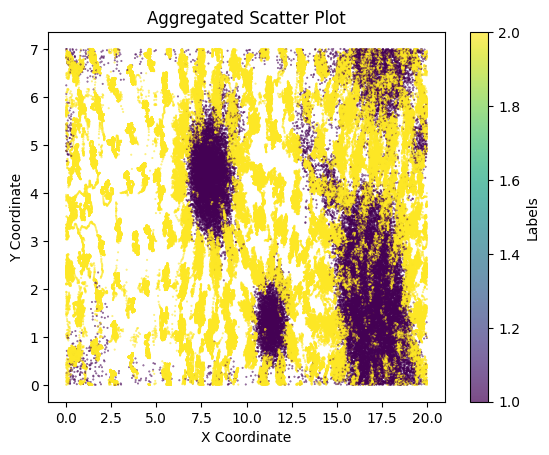

In [19]:
import matplotlib.pyplot as plt

plt.scatter(
    coordinates_array[:, 0], 
    coordinates_array[:, 1], 
    c=labels_array, 
    cmap='viridis', 
    alpha=0.7, 
    s=0.2  # size of the points
)
plt.colorbar(label="Labels")
plt.title("Aggregated Scatter Plot")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

In [1]:
import numpy as np

# Reduce the number of samples and dimensions
graphical_data = np.random.rand(10, 32, 32, 3)  # 10 samples of 32x32 RGB images
numerical_data = np.random.rand(10, 3)          # 10 samples, 3 numerical features
time_series_data = np.random.rand(10, 5, 2)     # 10 samples, 5 time steps, 2 features per step
target_output = np.random.rand(10, 1)           # 10 regression targets


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ graphical_input     │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 62, 62,    │        896 │ graphical_input[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 31, 31,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series_input   │ (None, 10, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 10, 64)    │     17,408 │ time_series_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 53824)     │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        384 │ numerical_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 32)        │     12,416 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graphical_features  │ (None, 128)       │  6,889,600 │ flatten_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_features  │ (None, 32)        │      2,080 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series_featur… │ (None, 32)        │      1,056 │ lstm_5[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_features      │ (None, 192)       │          0 │ graphical_featur… │
│ (Concatenate)       │                   │            │ numerical_featur… │
│                     │                   │            │ time_series_feat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │     12,352 │ fused_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,956,801 (26.54 MB)

 Trainable params: 6,956,801 (26.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - loss: 144.7121 - mae: 8.2317 - val_loss: 11.4754 - val_mae: 3.3803
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - loss: 32.1729 - mae: 4.8374 - val_loss: 11.5554 - val_mae: 3.3917
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - loss: 8.0629 - mae: 2.6096 - val_loss: 1.0281 - val_mae: 0.9904
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.9228 - mae: 0.8669 - val_loss: 0.1082 - val_mae: 0.2722
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 1.4072 - mae: 0.9830 - val_loss: 0.0684 - val_mae: 0.2073
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 0.5703 - mae: 0.6131 - val_loss: 0.0530 - val_mae: 0.1987
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.2787 - mae: 0.4300 - val_loss: 0.0589 - val_mae: 0.1941
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.2141 - mae: 0.3766 - val_loss: 0.0491 - val_mae: 0.1804
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.1683 - 

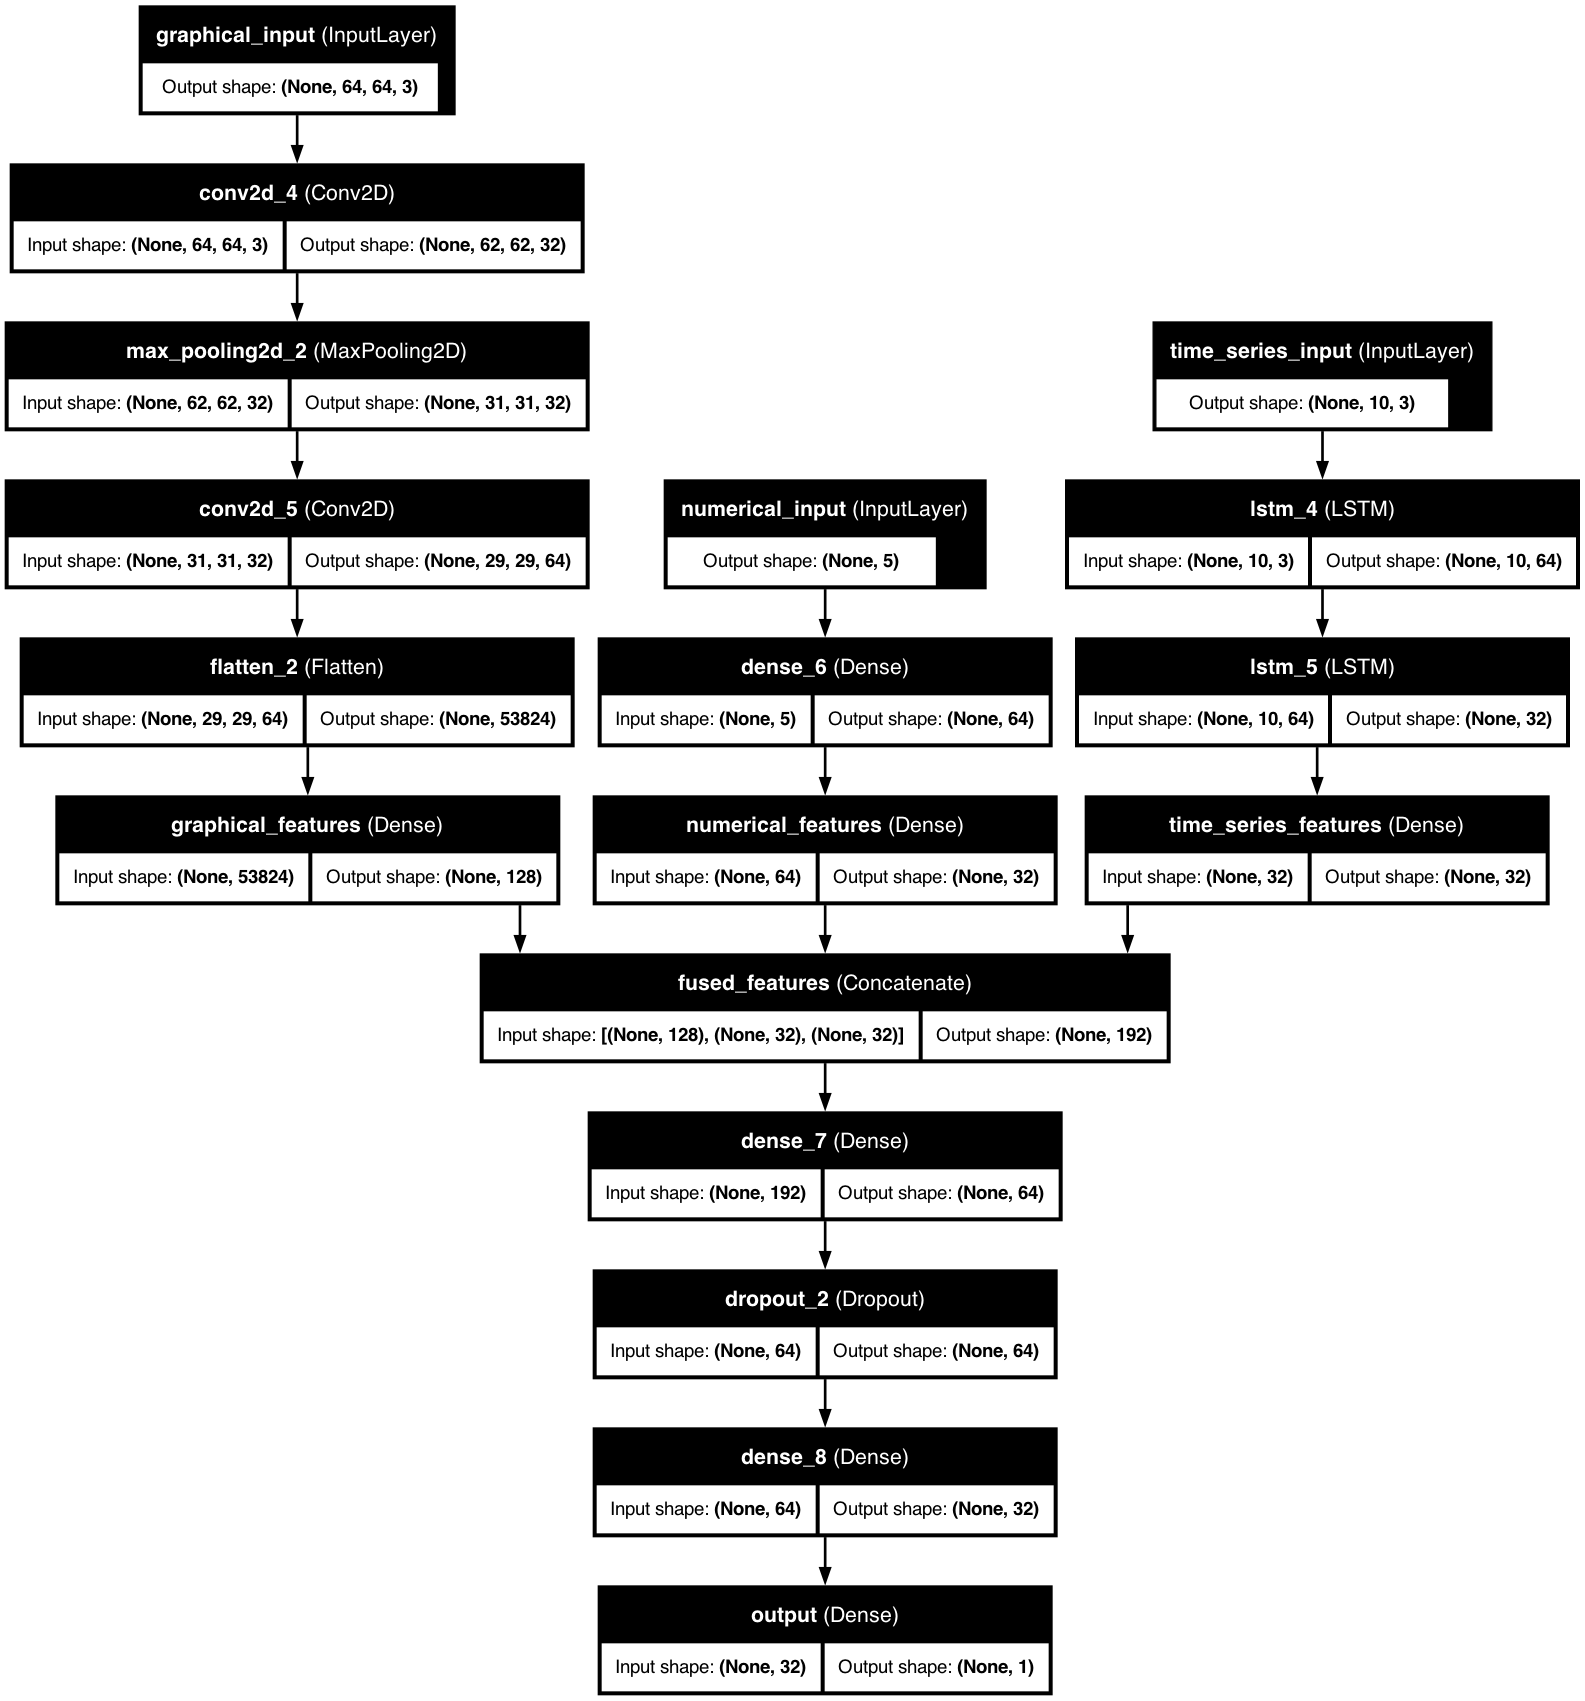

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import plot_model

# Step 1: Dummy Data Preparation
# Generate dummy data for three input types
graphical_data = np.random.rand(100, 64, 64, 3)    # Images
numerical_data = np.random.rand(100, 5)            # Numerical features
time_series_data = np.random.rand(100, 10, 3)      # Time-series data
target_output = np.random.rand(100, 1)             # Target variable

# Step 2: Model Definition
# Graphical branch
graphical_input = Input(shape=(64, 64, 3), name="graphical_input")
x1 = layers.Conv2D(32, (3, 3), activation='relu')(graphical_input)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(64, (3, 3), activation='relu')(x1)
x1 = layers.Flatten()(x1)
graphical_features = layers.Dense(128, activation='relu', name="graphical_features")(x1)

# Numerical branch
numerical_input = Input(shape=(5,), name="numerical_input")
x2 = layers.Dense(64, activation='relu')(numerical_input)
numerical_features = layers.Dense(32, activation='relu', name="numerical_features")(x2)

# Time-series branch
time_series_input = Input(shape=(10, 3), name="time_series_input")
x3 = layers.LSTM(64, return_sequences=True)(time_series_input)
x3 = layers.LSTM(32)(x3)
time_series_features = layers.Dense(32, activation='relu', name="time_series_features")(x3)

# Feature Fusion
combined_features = layers.Concatenate(name="fused_features")(
    [graphical_features, numerical_features, time_series_features]
)

# Fully connected layers for prediction
x = layers.Dense(64, activation='relu')(combined_features)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='linear', name="output")(x)

# Define the model
model = models.Model(
    inputs=[graphical_input, numerical_input, time_series_input],
    outputs=output
)

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print model summary
model.summary()

# Step 4: Train the Model
history = model.fit(
    [graphical_data, numerical_data, time_series_data],  # Inputs
    target_output,  # Target
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

# Generate and save the model architecture diagram
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=96
)


In [7]:
# Extract latent features from the fused layer
from tensorflow.keras.models import Model

feature_extractor = Model(inputs=model.input, outputs=model.get_layer("fused_features").output)
latent_features = feature_extractor.predict([graphical_data, numerical_data, time_series_data])

# Perform symbolic regression on latent features
import pysr
equations = pysr.PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "sin", "cos"]
).fit(latent_features, target_output)
print(equations)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step 


/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:2059: UserWarning: Note: you are running with 10 features or more. Genetic algorithms like used in PySR scale poorly with large numbers of features. You should run PySR for more `niterations` to ensure it can find the correct variables, and consider using a larger `maxsize`.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.970e+05
Head worker occupation: 19.5%
Progress: 1324 / 1500 total iterations (88.267%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           7.973e-02  1.594e+01  y = 0.55465
2           7.892e-02  1.016e-02  y = sin(x₁₂₇)
3           6.747e-02  1.568e-01  y = 0.47677 * x₅₂
4           5.992e-02  1.187e-01  y = sin(x₅₂ + -0.72982)
5           5.778e-02  3.629e-02  y = 0.71658 * (x₅₂ + x₉₃)
6           5.588e-02  3.342e-02  y = sin(x₅₂ + (x₁₃₉ - x₇₁))
7           5.586e-02  3.703e-04  y = sin(x₅₂ + (sin(x₁₃₉) - x₇₁))
8           5.550e-02  6.477e-03  y = sin(((x₁₃₉ - x₁₆₂) - x₇₁) + x₅₂)
10          5.517e-02  3.007e-03  y = sin(((x₁₃₉ - x₁₆₂) - x₇₁) + x₅₂) + x₁₆₆
11          5.501e-02  2.896e-03  y = ((((x₇₁ * x₁₃₉) - x₁₆₂) - x₇₁) + x₅₂) * 0.83851
12          5.501e-02  3.386e-05  y = sin(0.77348 * (x₅₂ + ((x₁₃₉ - x₅₇) - (x₇₁ * x₇₁))))
13

In [ ]:
# necessary imports and definitions for this section
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import torch.nn as nn
from sklearn.metrics import f1_score
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



#Used this tutorial for help: https://www.digitalocean.com/community/tutorials/writing-cnns-from-scratch-in-pytorch

#Preprocess the images (resize) so they are all the same size (32 x 32)
def toTensor(imageset):
    transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
 
    tensor = [transform(Image.fromarray(image)) for image in imageset]
    return torch.stack(tensor)


# Creating a CNN class
class ConvNeuralNet(nn.Module):

    def __init__(self, num_classes=4): #takes in number of classes, default at 4 for hurricane dataset
        super(ConvNeuralNet, self).__init__()
        #2 layers with a max pooling layer. 3 kernels for RGB data
        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(12) 
        self.conv_layer2 = nn.Conv2d(in_channels=12, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(12)
        self.max_pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu1 = nn.ReLU() 
        
        #another 2 layers with a max pooling layer
        self.conv_layer3 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1) # 2 more layers with another max pooling layer
        self.bn3 = nn.BatchNorm2d(24)
        self.conv_layer4 = nn.Conv2d(in_channels=24, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(24)
        self.max_pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu2 = nn.ReLU() 

        #another 2 layers with a max pooling layer
        self.conv_layer5 = nn.Conv2d(in_channels=24, out_channels=24, kernel_size=3, stride=1, padding=1) # 2 more layers with another max pooling layer
        self.bn5 = nn.BatchNorm2d(24)
        self.conv_layer6 = nn.Conv2d(in_channels=24, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(24)
        self.max_pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu3 = nn.ReLU() 

        #dropout layer to help with overfitting
        self.drop = nn.Dropout2d(p=0.5)
        
        # 32 x 32 tensor images, pooled 2x with kernel size = 2, so they're now 8x8
        # 8 x 8 x 24 (how many we generated)
        self.fc1 = nn.Linear( 4 * 4 * 24, num_classes) #linear layer that maps to the classes
    
    # Moving images through CNN    
    def forward(self, x): 
        out = self.conv_layer1(x) #first conv layer
        out = self.bn1(out) #batch normalization
        out = self.conv_layer2(out) #second conv layer
        out = self.bn2(out) #batch normalization
        out = self.max_pool1(out) #max pooling layer (dimensionality reduction)
        out = self.relu1(out) #relu activation
        
        out = self.conv_layer3(out) #third conv layer
        out = self.bn3(out) #batch normalization
        out = self.conv_layer4(out) #fourth conv layer
        out = self.bn4(out) #batch normalization
        out = self.max_pool2(out) #max pooling layer (dimensionality reduction)
        out = self.relu2(out) #relu activation

        out = self.conv_layer5(out) #third conv layer
        out = self.bn5(out) #batch normalization
        out = self.conv_layer6(out) #fourth conv layer
        out = self.bn6(out) #batch normalization
        out = self.max_pool3(out) #max pooling layer (dimensionality reduction)
        out = self.relu3(out) #relu activation

       
        out = self.drop(out) #dropout layer
        
        out = out.reshape(out.size(0), -1) # flattens to 1D before feeding to linear layers
        
        out = self.fc1(out) # fully connected layer
        return out




In [ ]:
# loading in the raw images 

disaster_list = ["hurricane-matthew"]

data = {}
split = "train"

with open('config.json') as config_file:
    config = json.load(config_file)
    # data_dir = "/home/jovyan/shared/course/data100-shared-readwrite/fa24_grad_project_data/satellite-image-data"
    data_dir = "../satellite-image-data"

for disaster in disaster_list:
    print(f"Loading {split} images and labels for {disaster} dataset...")
    images = get_images(data_dir, disaster, split=split)
    labels = get_labels(data_dir, disaster, split=split)
    data[disaster] = {"images": images, "labels": labels}

# choose hurricane-matthew from our labels list 
disaster = disaster_list[0]

#separate the labels and the images for our EDA
hurricane_matthew_labels = data[disaster]["labels"]
hurricane_matthew_images = data[disaster]["images"]

In [ ]:
# data cleaning and formatting for the CNN
random_0_indices = list(np.where(hurricane_matthew_labels == 0)[0])
random_1_indices = list(np.where(hurricane_matthew_labels == 1)[0])
random_3_indices = list(np.where(hurricane_matthew_labels == 3)[0])
random_2_indices = list(np.where(hurricane_matthew_labels == 2)[0])

display(len(random_0_indices)) #2631
display(len(random_1_indices)) #5236
display(len(random_2_indices)) #1544
display(len(random_3_indices)) #1740

# loader objects for PyTorch
images_tensor = toTensor(hurricane_matthew_images)
labels_tensor = torch.tensor(hurricane_matthew_labels, dtype = torch.long)


#Split into validation and training sets
X_train_CNN, X_valid_CNN, y_train_CNN, y_valid_CNN = train_test_split(images_tensor, labels_tensor, test_size=0.2, random_state=42)


#Create tensor datasets to load into the loader object
train_dataset = TensorDataset(X_train_CNN, y_train_CNN)
valid_dataset = TensorDataset(X_valid_CNN, y_valid_CNN)

#Create loader objects (preserves memory by only loading the images batch by batch)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=4)


In [ ]:
#finding the proportion of each label

len(hurricane_matthew_labels)
zero = 2631/len(hurricane_matthew_labels)
one = 5236/len(hurricane_matthew_labels)
two = 1544/len(hurricane_matthew_labels)
three = 1740/len(hurricane_matthew_labels)

print(zero)
print(one)
print(two)
print(three)


## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin

#converting my CNN into a form that I can use with GridSearchCV

class PyTorchCNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, num_classes=4, learning_rate=0.001, weight_decay=1e-4, momentum=0.9, num_epochs=50, batch_size=32):
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.momentum = momentum
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = ConvNeuralNet(num_classes=num_classes).to(self.device)
        self.loss_func = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

    def fit(self, X, y):
        train_dataset = TensorDataset(X, y)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0
            correct_train = 0
            total_train = 0

            for images, labels in train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_func(outputs, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item()
                _, predicted_train = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted_train == labels).sum().item()

            avg_loss = running_loss / len(train_loader)
            t_accuracy = 100 * correct_train / total_train

        return self

    def predict(self, X):
        self.model.eval()
        X = X.to(self.device)
        outputs = self.model(X)
        _, predicted = torch.max(outputs.data, 1)
        return predicted.cpu().numpy()

    def score(self, X, y):
        y_pred = self.predict(X)
        return f1_score(y.cpu().numpy(), y_pred, average='weighted')


# Define the parameters I want to test

param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'weight_decay': [1e-4, 1e-5],
    'momentum': [0.9, 0.95]
}

# initialize the custom class
cnn_estimator = PyTorchCNNClassifier()

# initialize and run GridSearchCV
grid_search = GridSearchCV(estimator=cnn_estimator, param_grid=param_grid, scoring='f1_weighted', cv=3, n_jobs=1)
grid_search.fit(X_train_CNN, y_train_CNN)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best score
print("Best score: ", grid_search.best_score_)


In [ ]:

# hyperparameters 
num_classes = 4 #number of classes in our dataset
learning_rate = 0.001 #initializing initial learning rate

# set device to run 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#setting up model using our custom class
cnn_model_11 = ConvNeuralNet(num_classes)

# using cross entropy for the loss function
class_weights = torch.tensor([0.23594296475652407, 0.46955430006277465, 0.13846291812393507, 0.1560398170567662], device=device)
loss_func = nn.CrossEntropyLoss(weight=class_weights)

# set optimizer for CNN (stochastic gradient descent)
optimizer = torch.optim.SGD(cnn_model_11.parameters(), lr=learning_rate, weight_decay = 1e-4, momentum = 0.9)

#takes ~20 mins to run!
num_epochs = 50 #number of times to run the CNN


In [ ]:
#Counters for visualization of training loss and accuracy
train_loss = []
train_accuracy = []
train_f1 = []


for epoch in range(num_epochs):
    #training mode
    cnn_model_11.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    true_labels = []
    pred_labels = []

    # user loader object to load the data
    for i, (images, labels) in enumerate(train_loader):  
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward through the CNN
        outputs = cnn_model_11(images) 
        loss = loss_func(outputs, labels) #calculate loss
        
        # Backpropagation, optimize parameters
        optimizer.zero_grad() #use SGD to optimize weights
        loss.backward() #check new gradient with loss function
        optimizer.step() #update weights

        running_loss += loss.item() #add all loss over this loop to running_loss

        _, predicted_train = torch.max(outputs.data, 1) # get current prediction for this epoch
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item() #compare prediction with label

        true_labels.extend(labels.cpu().numpy()) #adding true labels to a flat list
        pred_labels.extend(predicted_train.cpu().numpy()) #adding pred labels to a flat list
    

    
    # Calculate average loss and accuracy over the epoch
    avg_loss = running_loss / len(train_loader) #gives the average loss over the epoch
    train_loss.append(avg_loss)
    t_accuracy = 100 * correct_train / total_train
    train_accuracy.append(t_accuracy)
    train_f1.append(f1_score(true_labels, pred_labels, average='weighted'))
    
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {train_accuracy[-1]:.2f}%, F1 Score: {train_f1[-1]:.4f}')


In [ ]:
#Running validation set through the optimized CNN to calculate accuracy

cnn_model_11.eval() #model in evaluation mode


#collecting metrics from validation evaluation run as well
valid_running_loss = 0.0
correct_valid = 0
total_valid = 0
true_labels_valid = []
pred_labels_valid = []

#do not need gradient optimization for validation set
with torch.no_grad(): 
    for images, labels in valid_loader: 
        images = images.to(device)
        labels = labels.to(device)
        outputs = cnn_model_11(images)

        #loss
        loss = loss_func(outputs, labels)
        valid_running_loss += loss.item()

        #accuracy
        _, predicted_valid = torch.max(outputs.data, 1)
        total_valid += labels.size(0)
        correct_valid += (predicted_valid == labels).sum().item()

        true_labels_valid.extend(labels.cpu().numpy())
        pred_labels_valid.extend(predicted_valid.cpu().numpy())

avg_valid_loss = valid_running_loss / len(valid_loader)
valid_accuracy =  100 * correct_valid / total_valid
valid_f1 = f1_score(true_labels_valid, pred_labels_valid, average='weighted')
    
print(f'Validation Loss: {avg_valid_loss:.4f}')
print(f'Validation Accuracy: {valid_accuracy:.2f}%')
print(f'Validation F1 Score: {valid_f1:.4f}')

In [ ]:
#Visualization of training loss and accuracy

xplot = np.arange(num_epochs)

fig1, ax1 = plt.subplots(2, 1, sharex = True)
ax1[0].set_title("Training metrics for Hurricane Matthew data")
ax1[0].plot(xplot, train_loss, 'blue', label="Training Loss")
ax1[0].set_ylabel('Loss')
ax1[0].legend()
ax1[1].plot(xplot, train_accuracy, 'red', label='Training Accuracy')
ax1[1].set_ylabel('Accuracy [%]')
ax1[1].legend()
plt.xlabel('Epochs')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_cm = confusion_matrix(true_labels, pred_labels)
test_cm = confusion_matrix(true_labels_valid, pred_labels_valid)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(train_cm, display_labels=[0, 1, 2, 3]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Hurricane Training Set Confusion Matrix")
ConfusionMatrixDisplay(test_cm, display_labels=[0, 1, 2 ,3]).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Hurricane Validation Set Confusion Matrix")

plt.show()

## Performance Assessment

Use the model to generate predictions for the `test_images_hurricane-matthew.npz` images. This should be in a CSV file `test_images_hurricane-matthew_predictions.csv` consisting of a single column with no header, with a 0-3 prediction of the damage level. The prediction in row *i* should correspond to the *i*th image.

In [ ]:
test_im_hurricane_path = os.path.join(data_dir, "test_images_hurricane-matthew.npz")
test_im_hurricane = load_images(test_im_hurricane_path)

In [ ]:
plt.imshow(test_im_hurricane[0]);

In [ ]:
test_sobel_edges = img_to_sobel(test_im_hurricane)
test_lbp = img_to_LBP(test_im_hurricane)  
test_red, test_green, test_blue = image_to_RGB(test_im_hurricane)
test_red_log = np.log(np.array(test_red))
test_green_log = np.log(np.array(test_green))
test_blue_log = np.log(np.array(test_blue))  # not used, keeping for consistency
test_gabor = img_to_gabor(test_im_hurricane)

# Combine all features into df
test_features = pd.DataFrame({
    'Sobel_Edges': test_sobel_edges,
    "LBP": test_lbp,
    'Red_Log': test_red_log,
    'Green_Log': test_green_log,
    'Gabor': test_gabor
})

## Logistic

In [ ]:
test_predictions = model.predict(test_features)
output_path = "logistic_test_images_hurricane_predictions.csv"
pd.DataFrame(test_predictions).to_csv(output_path, index=False, header=False)

## Gradient

In [ ]:
pca_test = pca_hur.transform(test_features)

test_predictions = predict(pca_test, weights, bias)

output_path = "gradient_logistic_test_images_hurricane_predictions.csv"
pd.DataFrame(test_predictions).to_csv(output_path, index=False, header=False)

print(f"Predictions saved to {output_path}")

## CNN

In [ ]:
# Define a loader for the test dataset
test_images = resize(test_im_hurricane)
test_features = toTensor(test_images)

test_dataset = TensorDataset(test_features)

test_loader =  DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

cnn_model_11.eval() #model in test mode

test_predictions = []

#do not need gradient optimization 
with torch.no_grad(): 
    for images in test_loader: 
        images = images[0].to(device)
        outputs = cnn_model_11(images)

        _, predicted = torch.max(outputs.data, 1)

        test_predictions.extend(predicted.cpu().numpy())

output_path = "cnn_test_images_hurricane-matthew_predictions_v2.csv"
predictions_df = pd.DataFrame(test_predictions, columns=["pred"])
predictions_df.to_csv(output_path, index=False)

print(f"Predictions saved to {output_path}")